# 02 Data Understanding

ขั้นตอนนี้ตรวจสอบคุณภาพและความต่อเนื่องของข้อมูล สำรวจแนวโน้มและความผันผวนของ IMI กลุ่มเชื้อเพลิง ปุ๋ย และนม ตรวจจำนวน observation รายวันของข้อมูลภายนอก และวิเคราะห์ correlation กับ lag เบื้องต้น

การวิเคราะห์ในขั้นนี้เป็นเชิงสำรวจ ยังไม่ใช้ test set เพื่อเลือก feature หรือเปลี่ยนกลุ่มสินค้า

## 1. โหลดข้อมูลจาก metadata

อ่านชื่อไฟล์จาก `sources.json` แทนการ hard-code ชื่อ snapshot และตรวจ SHA-256 ก่อนวิเคราะห์

In [1]:
from __future__ import annotations

import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / 'PROJECT_SCOPE.md').exists()
)
RAW_DIR = ROOT / 'data' / 'raw'
METRICS_DIR = ROOT / 'logs' / 'metrics'
FIGURES_DIR = ROOT / 'reports' / 'figures'
METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

sources = json.loads((RAW_DIR / 'sources.json').read_text(encoding='utf-8'))['sources']

def latest_source(prefix: str) -> dict:
    return next(item for item in reversed(sources) if item['source_id'].startswith(prefix))

source_items = {
    'IMI': latest_source('imi-monthly-'),
    'DEXTHUS': latest_source('dexthus-'),
    'DCOILBRENTEU': latest_source('dcoilbrenteu-'),
}
for name, item in source_items.items():
    path = RAW_DIR / item['file']
    assert path.exists(), f'ไม่พบไฟล์ {path}'
    assert sha256(path) == item['sha256'], f'checksum ไม่ตรง: {path.name}'

imi = pd.read_csv(
    RAW_DIR / source_items['IMI']['file'],
    dtype={'commodityCode': 'string'},
)
imi['commodityCode'] = imi['commodityCode'].str.zfill(3)
imi['date'] = pd.to_datetime(dict(year=imi['year'] - 543, month=imi['month'], day=1))
imi = imi.sort_values(['commodityCode', 'date']).reset_index(drop=True)

daily = {}
for series_id in ('DEXTHUS', 'DCOILBRENTEU'):
    frame = pd.read_csv(
        RAW_DIR / source_items[series_id]['file'],
        na_values=['.'],
    )
    frame['observation_date'] = pd.to_datetime(frame['observation_date'], errors='raise')
    daily[series_id] = frame.sort_values('observation_date').reset_index(drop=True)

print(f'IMI: {len(imi):,} แถว')
print(f'DEXTHUS: {len(daily["DEXTHUS"]):,} แถว')
print(f'DCOILBRENTEU: {len(daily["DCOILBRENTEU"]):,} แถว')

IMI: 25,752 แถว
DEXTHUS: 11,931 แถว
DCOILBRENTEU: 10,270 แถว


## 2. คุณภาพและความต่อเนื่องของข้อมูล

ตรวจ schema, duplicate, missing value, ช่วงวันที่ และความต่อเนื่องรายรหัส โดยแยกค่าว่างในข้อมูลรายวันออกจากวันที่ไม่มีแถวในไฟล์

In [2]:
expected_imi_columns = {
    'commodityCode', 'commodityNameTH', 'month', 'year', 'yearBase',
    'index', 'change', 'changeYear', 'changeAVG', 'level', 'createdAt', 'date',
}
assert expected_imi_columns <= set(imi.columns)
assert (imi['index'] > 0).all(), 'พบค่า IMI index ที่ไม่เป็นบวก ซึ่งใช้ log ไม่ได้'

quality_rows = [{
    'dataset': 'IMI',
    'rows': len(imi),
    'start': imi['date'].min().date(),
    'end': imi['date'].max().date(),
    'missing_value': int(imi['index'].isna().sum()),
    'duplicate_key': int(imi.duplicated(['commodityCode', 'date']).sum()),
}]
for series_id, frame in daily.items():
    filtered = frame[frame['observation_date'] >= '2000-01-01']
    quality_rows.append({
        'dataset': series_id,
        'rows': len(filtered),
        'start': filtered['observation_date'].min().date(),
        'end': filtered['observation_date'].max().date(),
        'missing_value': int(filtered[series_id].isna().sum()),
        'duplicate_key': int(filtered['observation_date'].duplicated().sum()),
    })
quality = pd.DataFrame(quality_rows)
quality.to_csv(METRICS_DIR / '02_data_quality.csv', index=False)
display(quality)

all_months = pd.period_range(imi['date'].min(), imi['date'].max(), freq='M')
coverage_rows = []
for code, group in imi.groupby('commodityCode'):
    observed = pd.PeriodIndex(group['date'], freq='M')
    coverage_rows.append({
        'commodity_code': code,
        'commodity_name_th': group['commodityNameTH'].iloc[0],
        'rows': len(group),
        'start': group['date'].min().date(),
        'end': group['date'].max().date(),
        'missing_months_full_range': len(all_months.difference(observed)),
    })
coverage = pd.DataFrame(coverage_rows)
discontinued = coverage[coverage['missing_months_full_range'] > 0].copy()
coverage.to_csv(METRICS_DIR / '02_imi_code_coverage.csv', index=False)
display(discontinued)
print(f'createdAt ที่แตกต่างกัน: {imi["createdAt"].nunique()} ค่า')
print(f'createdAt: {imi["createdAt"].iloc[0]}')

,dataset,rows,start,end,missing_value,duplicate_key
0,IMI,25752,2000-01-01,2026-08-01,0,0
1,DEXTHUS,6975,2000-01-03,2026-09-25,272,0
2,DCOILBRENTEU,6977,2000-01-03,2026-09-29,501,0


,commodity_code,commodity_name_th,rows,start,end,missing_months_full_range
35,315,3.15 หลอดภาพโทรทัศน์และส่วนประกอบ,204,2000-01-01,2016-12-01,116
47,401,4.1 สัตว์มีชีวิตไม่ได้ทำพันธุ์,300,2000-01-01,2024-12-01,20
63,417,4.17 กล้องถ่ายรูป อุปกรณ์และส่วนประกอบ,288,2000-01-01,2023-12-01,32


createdAt ที่แตกต่างกัน: 1 ค่า
createdAt: 2026-09-28T02:58:06.619704Z


## 3. จำนวน observation ของข้อมูลภายนอก

นับค่าที่ไม่ว่างของแต่ละเดือนทั้งเดือน และเฉพาะวันที่ 1–24 ตาม Scope v3 forecast origin คือวันที่ 15 ของเดือน t+2 จึงใช้ค่าเฉลี่ยเต็มเดือน t+1 เป็น recent-information feature หลัก ส่วนค่าเฉลี่ยวันที่ 1–24 ของเดือน t+1 ใช้เป็น sensitivity check ค่าว่างไม่ถูกแทนด้วยศูนย์

,series,months,median_non_null_through_24,min_non_null_through_24,min_non_null_full_month
0,DCOILBRENTEU,321,16.0,7,9
1,DEXTHUS,321,17.0,13,18


,series,month,non_null_through_24,full_non_null
0,DEXTHUS,2021-01,13,18
1,DCOILBRENTEU,2002-11,7,10
2,DCOILBRENTEU,2006-03,7,9


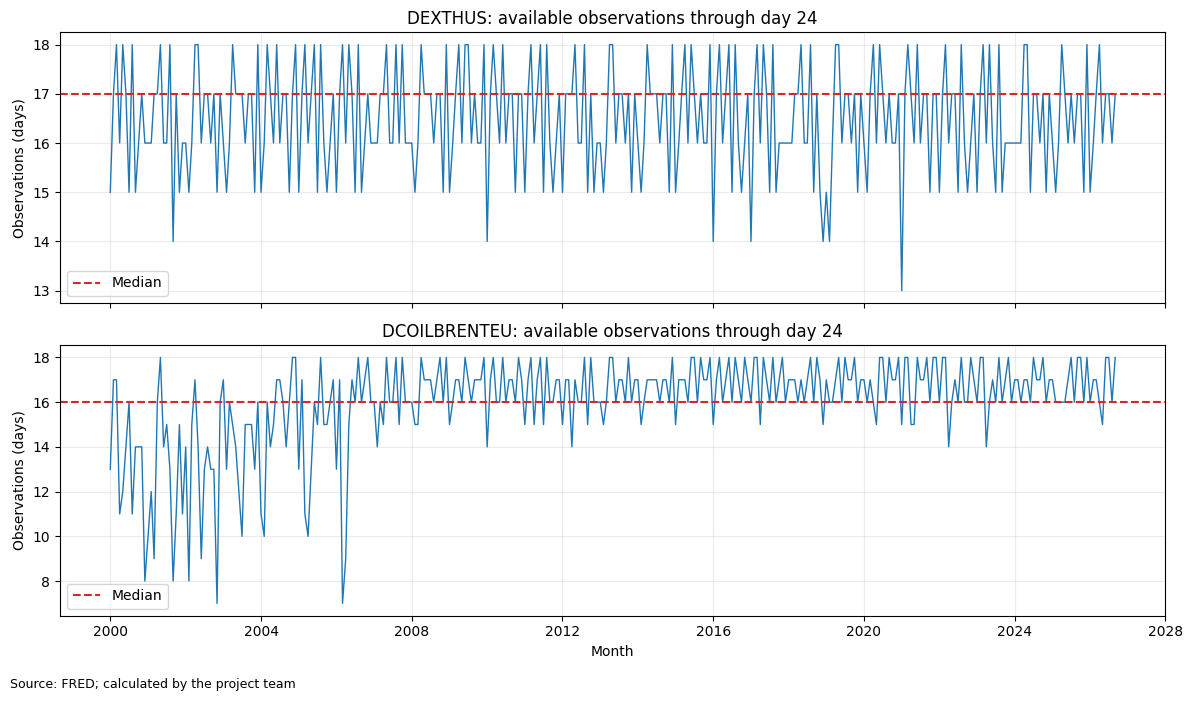

In [3]:
coverage_parts = []
for series_id, frame in daily.items():
    frame = frame[frame['observation_date'] >= '2000-01-01'].copy()
    frame['month'] = frame['observation_date'].dt.to_period('M')
    frame['day'] = frame['observation_date'].dt.day
    full = frame.groupby('month')[series_id].agg(full_rows='size', full_non_null='count')
    through_24 = (
        frame[frame['day'] <= 24]
        .groupby('month')[series_id]
        .agg(rows_through_24='size', non_null_through_24='count')
    )
    combined = full.join(through_24).reset_index()
    combined.insert(0, 'series', series_id)
    coverage_parts.append(combined)
external_coverage = pd.concat(coverage_parts, ignore_index=True)
external_coverage['month'] = external_coverage['month'].astype(str)
external_coverage.to_csv(METRICS_DIR / '02_external_monthly_coverage.csv', index=False)

coverage_summary = (
    external_coverage.groupby('series')
    .agg(
        months=('month', 'size'),
        median_non_null_through_24=('non_null_through_24', 'median'),
        min_non_null_through_24=('non_null_through_24', 'min'),
        min_non_null_full_month=('full_non_null', 'min'),
    )
    .reset_index()
)
display(coverage_summary)

minimum_months = external_coverage.merge(
    external_coverage.groupby('series', as_index=False)['non_null_through_24'].min(),
    on=['series', 'non_null_through_24'],
)
display(minimum_months[['series', 'month', 'non_null_through_24', 'full_non_null']])

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for axis, series_id in zip(axes, ('DEXTHUS', 'DCOILBRENTEU')):
    plot_data = external_coverage[external_coverage['series'] == series_id].copy()
    plot_data['date'] = pd.to_datetime(plot_data['month'])
    axis.plot(plot_data['date'], plot_data['non_null_through_24'], linewidth=1)
    axis.axhline(plot_data['non_null_through_24'].median(), color='tab:red', linestyle='--', label='Median')
    axis.set_title(f'{series_id}: available observations through day 24')
    axis.set_ylabel('Observations (days)')
    axis.grid(alpha=0.25)
    axis.legend()
axes[-1].set_xlabel('Month')
fig.text(0.01, 0.01, 'Source: FRED; calculated by the project team', fontsize=9)
fig.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig(FIGURES_DIR / '02_external_observation_coverage.png', dpi=180, bbox_inches='tight')
plt.show()

### 3.1 ตรวจเดือนที่ Brent มีข้อมูลน้อย

Scope ข้อ 5.3 กำหนดให้ระบุเดือนที่ Brent มี observation น้อยและสาเหตุ เกณฑ์ที่ใช้คือเดือนที่มีค่าไม่ว่างทั้งเดือนไม่เกิน 10 วัน แต่ละวันที่ Brent เป็นค่าว่างจะตรวจว่าเป็นวันจันทร์ถึงศุกร์หรือไม่ และ DEXTHUS ของวันเดียวกันมีค่าหรือไม่ หาก DEXTHUS มีค่า แปลว่าตลาดการเงินสหรัฐฯ เปิดทำการในวันนั้น ค่าว่างของ Brent จึงไม่ได้เกิดจากวันหยุดของสหรัฐฯ

In [4]:
LOW_COVERAGE_MAX_DAYS = 10
brent_daily = daily['DCOILBRENTEU']
brent_daily = brent_daily[brent_daily['observation_date'] >= '2000-01-01'].copy()
fx_by_date = daily['DEXTHUS'].set_index('observation_date')['DEXTHUS']
brent_coverage = external_coverage[external_coverage['series'] == 'DCOILBRENTEU']
low_months = brent_coverage.loc[
    brent_coverage['full_non_null'] <= LOW_COVERAGE_MAX_DAYS, 'month'
].tolist()

gap_rows = []
for month in low_months:
    rows = brent_daily[brent_daily['observation_date'].dt.strftime('%Y-%m') == month]
    missing = rows[rows['DCOILBRENTEU'].isna()]
    missing_dates = missing['observation_date']
    fx_on_missing = fx_by_date.reindex(missing_dates)
    available = rows['DCOILBRENTEU'].dropna()
    gap_rows.append({
        'month': month,
        'rows_in_file': len(rows),
        'non_null_full_month': len(available),
        'non_null_through_24': int(rows.loc[rows['observation_date'].dt.day <= 24, 'DCOILBRENTEU'].notna().sum()),
        'missing_days': len(missing),
        'missing_on_weekdays': int((missing_dates.dt.dayofweek < 5).sum()),
        'missing_with_fx_value': int(fx_on_missing.notna().sum()),
        'missing_dates': ', '.join(missing_dates.dt.strftime('%d').tolist()),
        'brent_min_usd': available.min(),
        'brent_max_usd': available.max(),
        'brent_mean_usd': available.mean(),
    })
brent_gaps = pd.DataFrame(gap_rows)
brent_gaps.to_csv(METRICS_DIR / '02_brent_low_coverage_months.csv', index=False)
display(brent_gaps.round(2))

# เดือนเหล่านี้ใช้เป็น feature ได้เพียงแถวที่ t อยู่ระหว่าง 1 เดือนก่อนถึง 6 เดือนหลังเดือนนั้น
# (lead t+1, การเปลี่ยนแปลงย้อนหลังสูงสุด 3 เดือน และ rolling volatility 6 เดือน)
latest_affected_t = (pd.PeriodIndex(low_months, freq='M').max() + 6).to_timestamp()
print(f'เดือน Brent ที่มีข้อมูลน้อย: {", ".join(low_months)}')
print(f'แถวสุดท้ายที่อาจได้รับผลคือ t = {latest_affected_t:%Y-%m} ซึ่งอยู่ในช่วง train เริ่มต้น (ถึง 2014-12)')

,month,rows_in_file,non_null_full_month,non_null_through_24,missing_days,missing_on_weekdays,missing_with_fx_value,missing_dates,brent_min_usd,brent_max_usd,brent_mean_usd
0,2000-12,21,10,8,11,11,10,"05, 07, 08, 12, 13, 14, 21, 22, 25, 26, 29",22.29,31.59,25.88
1,2002-11,21,10,7,11,11,10,"05, 06, 08, 11, 12, 13, 14, 21, 22, 26, 27",23.33,25.78,24.65
2,2006-03,23,9,7,14,14,14,"02, 03, 06, 09, 14, 15, 16, 17, 20, 21, 23, 28...",58.42,65.95,61.32


เดือน Brent ที่มีข้อมูลน้อย: 2000-12, 2002-11, 2006-03
แถวสุดท้ายที่อาจได้รับผลคือ t = 2006-09 ซึ่งอยู่ในช่วง train เริ่มต้น (ถึง 2014-12)


## 4. แนวโน้ม ความผันผวน และเดือนที่ดัชนีไม่ขยับ

คำนวณการเปลี่ยนแปลงแบบ log ระยะ 1 และ 2 เดือน โดยรายงานส่วนเบี่ยงเบนมาตรฐานของการเปลี่ยนแปลง 2 เดือน และสัดส่วนการเปลี่ยนแปลง 1 เดือนที่เท่ากับศูนย์

,commodity_code,group,months,index_min,index_max,mean_log_change_1m_pct,std_log_change_1m_pct,std_log_change_2m_pct,zero_change_months,zero_change_share_pct
0,100,Fuel,320,23.0,144.3,0.518,5.411,9.118,4,1.254
1,318,Fertilizer,320,44.2,112.8,0.222,2.868,4.969,38,11.912
2,402,Dairy products,320,49.4,153.2,0.318,1.792,2.879,19,5.956


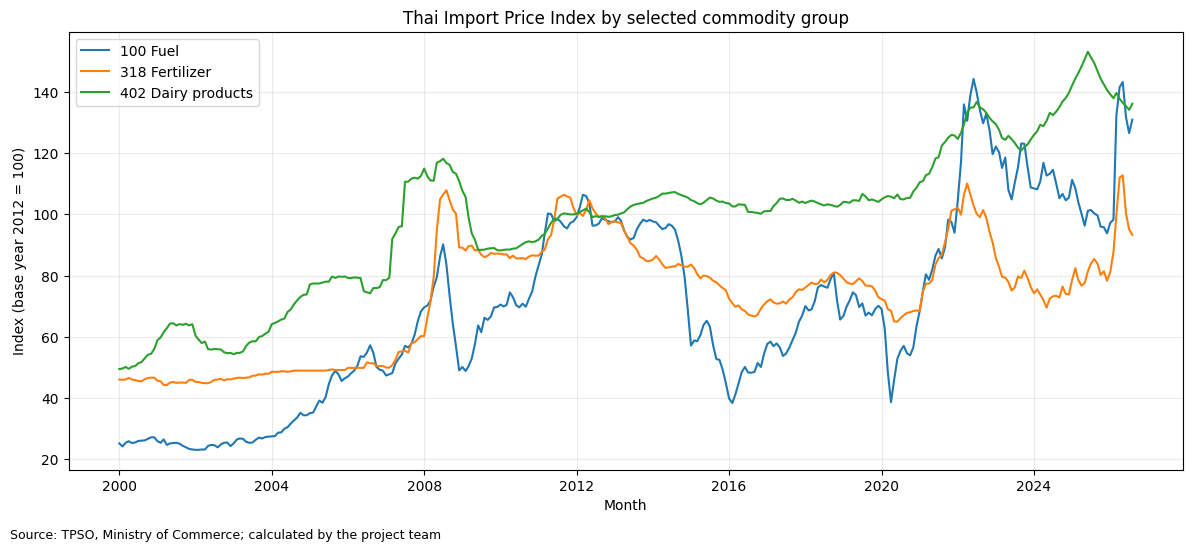

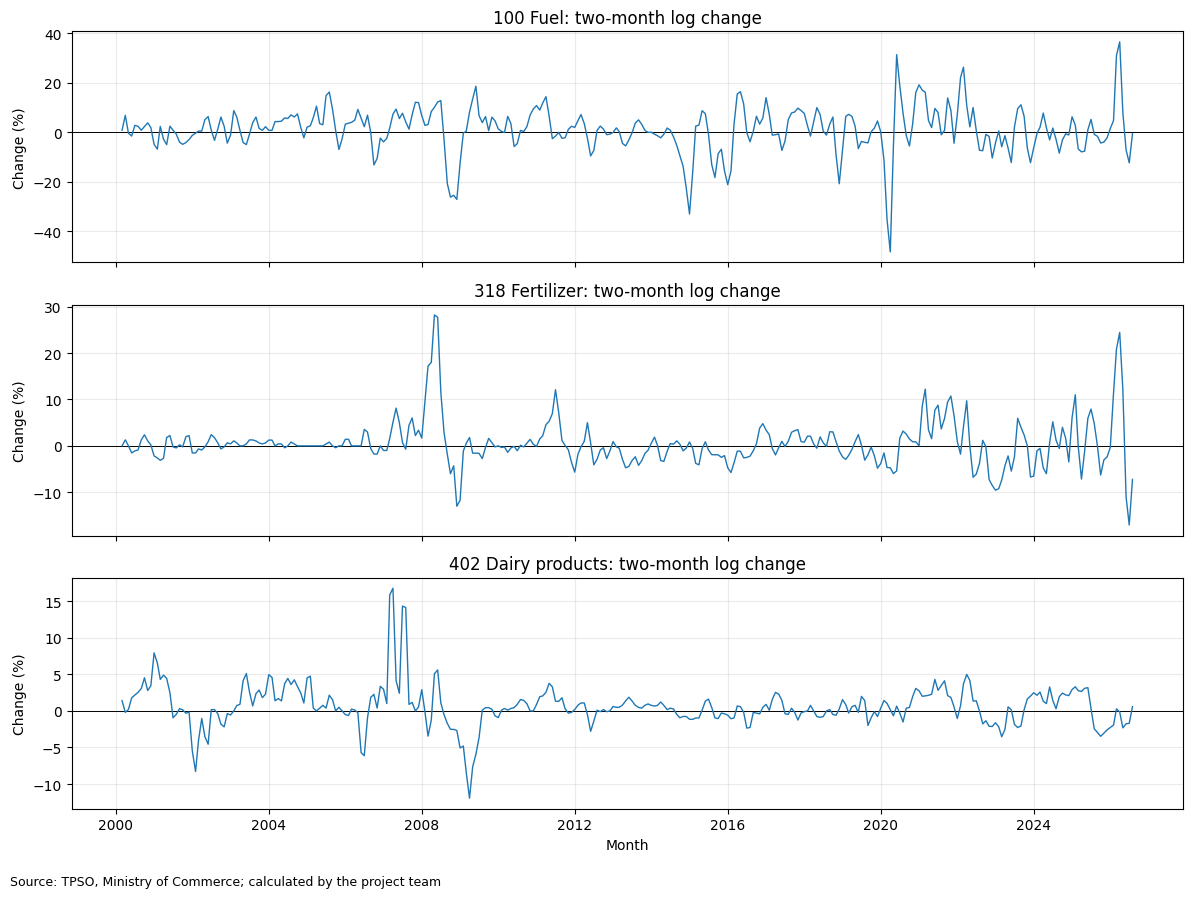

In [5]:
GROUPS = {
    '100': 'Fuel',
    '318': 'Fertilizer',
    '402': 'Dairy products',
}
group_frames = {}
statistics = []
for code, label in GROUPS.items():
    frame = imi[imi['commodityCode'] == code].copy().sort_values('date')
    frame['log_change_1m_pct'] = 100 * np.log(frame['index'] / frame['index'].shift(1))
    frame['log_change_2m_pct'] = 100 * np.log(frame['index'] / frame['index'].shift(2))
    valid_1m = frame['log_change_1m_pct'].dropna()
    valid_2m = frame['log_change_2m_pct'].dropna()
    group_frames[code] = frame
    statistics.append({
        'commodity_code': code,
        'group': label,
        'months': len(frame),
        'index_min': frame['index'].min(),
        'index_max': frame['index'].max(),
        'mean_log_change_1m_pct': valid_1m.mean(),
        'std_log_change_1m_pct': valid_1m.std(ddof=1),
        'std_log_change_2m_pct': valid_2m.std(ddof=1),
        'zero_change_months': int(np.isclose(valid_1m, 0, atol=1e-12).sum()),
        'zero_change_share_pct': 100 * np.isclose(valid_1m, 0, atol=1e-12).mean(),
    })
group_statistics = pd.DataFrame(statistics)
group_statistics.to_csv(METRICS_DIR / '02_imi_group_statistics.csv', index=False)
display(group_statistics.round(3))

fig, axis = plt.subplots(figsize=(12, 5.5))
for code, label in GROUPS.items():
    frame = group_frames[code]
    axis.plot(frame['date'], frame['index'], label=f'{code} {label}', linewidth=1.5)
axis.set_title('Thai Import Price Index by selected commodity group')
axis.set_xlabel('Month')
axis.set_ylabel('Index (base year 2012 = 100)')
axis.grid(alpha=0.25)
axis.legend()
fig.text(0.01, 0.01, 'Source: TPSO, Ministry of Commerce; calculated by the project team', fontsize=9)
fig.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig(FIGURES_DIR / '02_imi_trends.png', dpi=180, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for axis, (code, label) in zip(axes, GROUPS.items()):
    frame = group_frames[code]
    axis.axhline(0, color='black', linewidth=0.7)
    axis.plot(frame['date'], frame['log_change_2m_pct'], linewidth=1)
    axis.set_title(f'{code} {label}: two-month log change')
    axis.set_ylabel('Change (%)')
    axis.grid(alpha=0.25)
axes[-1].set_xlabel('Month')
fig.text(0.01, 0.01, 'Source: TPSO, Ministry of Commerce; calculated by the project team', fontsize=9)
fig.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig(FIGURES_DIR / '02_imi_two_month_changes.png', dpi=180, bbox_inches='tight')
plt.show()

## 5. Correlation และ lag correlation

แปลงข้อมูลภายนอกเป็นค่าเฉลี่ยรายเดือนโดยข้ามค่าว่าง แล้วคำนวณ log change 1 เดือน การทดสอบ lag ใช้ correlation ระหว่างการเปลี่ยนแปลง IMI เดือน `t` กับการเปลี่ยนแปลงตัวแปรภายนอกเดือน `t-lag` ตั้งแต่ lag 0–6 เดือน ผลนี้ใช้เพื่อทำความเข้าใจข้อมูลเท่านั้น ไม่ใช้เลือก feature จาก test set

external_series               DCOILBRENTEU                      DEXTHUS  \
lag_months                               0      1      2      3       0   
commodity_code group                                                      
100            Fuel                  0.817  0.452  0.094 -0.072  -0.065   
318            Fertilizer            0.286  0.306  0.210  0.065   0.080   
402            Dairy products        0.082  0.078 -0.021  0.137  -0.141   

external_series                                     
lag_months                         1      2      3  
commodity_code group                                
100            Fuel           -0.117 -0.050 -0.081  
318            Fertilizer      0.039 -0.054 -0.101  
402            Dairy products -0.103  0.042 -0.008

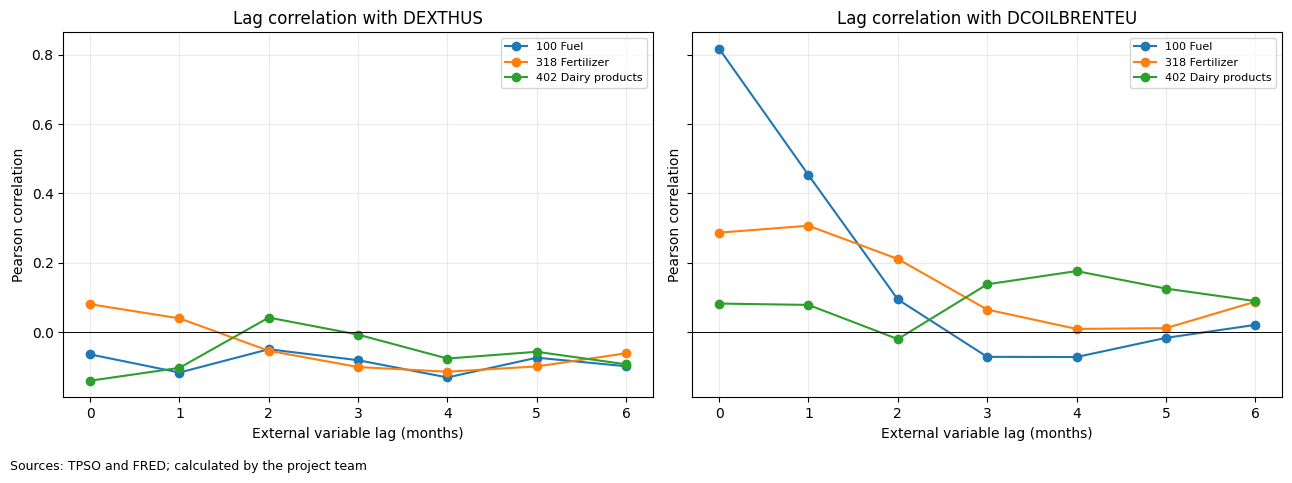

In [6]:
external_monthly = {}
for series_id, frame in daily.items():
    selected = frame[frame['observation_date'] >= '2000-01-01'].copy()
    selected['date'] = selected['observation_date'].dt.to_period('M').dt.to_timestamp()
    monthly_average = selected.groupby('date')[series_id].mean()
    external_monthly[series_id] = pd.DataFrame({
        'monthly_average': monthly_average,
        'log_change_1m_pct': 100 * np.log(monthly_average / monthly_average.shift(1)),
    })

correlation_rows = []
for code, label in GROUPS.items():
    imi_change = group_frames[code].set_index('date')['log_change_1m_pct']
    for series_id, frame in external_monthly.items():
        for lag in range(7):
            aligned = pd.concat([
                imi_change.rename('imi_change'),
                frame['log_change_1m_pct'].shift(lag).rename('external_change'),
            ], axis=1).dropna()
            correlation_rows.append({
                'commodity_code': code,
                'group': label,
                'external_series': series_id,
                'lag_months': lag,
                'n': len(aligned),
                'pearson_correlation': aligned['imi_change'].corr(aligned['external_change']),
            })
correlations = pd.DataFrame(correlation_rows)
correlations.to_csv(METRICS_DIR / '02_lag_correlations.csv', index=False)
display(correlations[correlations['lag_months'] <= 3].pivot_table(
    index=['commodity_code', 'group'],
    columns=['external_series', 'lag_months'],
    values='pearson_correlation',
).round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for axis, series_id in zip(axes, ('DEXTHUS', 'DCOILBRENTEU')):
    for code, label in GROUPS.items():
        selected = correlations[
            (correlations['commodity_code'] == code)
            & (correlations['external_series'] == series_id)
        ]
        axis.plot(selected['lag_months'], selected['pearson_correlation'], marker='o', label=f'{code} {label}')
    axis.axhline(0, color='black', linewidth=0.7)
    axis.set_title(f'Lag correlation with {series_id}')
    axis.set_xlabel('External variable lag (months)')
    axis.set_ylabel('Pearson correlation')
    axis.set_xticks(range(7))
    axis.grid(alpha=0.25)
    axis.legend(fontsize=8)
fig.text(0.01, 0.01, 'Sources: TPSO and FRED; calculated by the project team', fontsize=9)
fig.tight_layout(rect=(0, 0.04, 1, 1))
fig.savefig(FIGURES_DIR / '02_lag_correlations.png', dpi=180, bbox_inches='tight')
plt.show()

## 6. Pass-through lag จากราคานำเข้าไปราคาในประเทศ (RQ4ข)

IMI เป็นราคา C.I.F. ในรูปดอลลาร์สหรัฐ ส่วน SME จ่ายราคาในประเทศเป็นบาท ระยะเตือนจริงต่อผู้ใช้จึงขึ้นกับว่าราคาในประเทศตามหลังราคานำเข้ากี่เดือน ส่วนนี้วัด lag ดังกล่าวตาม Scope หัวข้อ 13

- **ราคานำเข้าในรูปบาท** = IMI × ค่าเฉลี่ยรายเดือนของ DEXTHUS ใช้การเปลี่ยนแปลง log รายเดือน (×100)
- **แบบจำลอง** distributed lag: `Δlog(ราคาในประเทศ)_t = a + Σ_{k=0}^{12} b_k Δlog(ราคานำเข้าบาท)_{t−k} + dummy เดือน + e_t` และใช้ Newey–West HAC standard error ที่ 12 lags
- **cumulative pass-through** ที่ lag k = b_0 + … + b_k และ **median lag** คือ k แรกที่ cumulative ถึงครึ่งหนึ่งของค่ารวม 12 เดือน คำนวณเฉพาะเมื่อค่ารวมเป็นบวก
- **ข้อมูลที่ใช้** เฉพาะเดือนก่อน 2019-01 เพื่อไม่ให้ช่วง test มีผลต่อเรื่องที่เล่า ผลส่วนนี้ไม่ใช้เลือก feature, horizon หรือ threshold

คู่ข้อมูลที่ตรวจ:
- IMI นม (402) กับ CPI นมและผลิตภัณฑ์นม (11320): ข้อมูลยาวที่สุด จึงเป็นผลหลัก
- IMI นม กับ PPI ผลิตภัณฑ์นม (3105)
- IMI ปุ๋ย (318) กับ PPI 3201 ซึ่งรวมปุ๋ยกับพลาสติก

PPI มีข้อมูลก่อน 2019 เพียง 48 เดือน ผลจาก PPI จึงเป็นหลักฐานอ่อน

,pair,start,end,n_obs,n_params,cumulative_12m,cumulative_12m_ci_low,cumulative_12m_ci_high,p_cumulative_zero,p_all_lags_zero,median_lag_months,lag_with_largest_b
0,IMI 402 นม → CPI 11320 นมและผลิตภัณฑ์นม,2002-01-01,2018-12-01,204,25,0.088,-0.000,0.177,0.051,0.0,4.0,4
1,IMI 402 นม → PPI 3105 ผลิตภัณฑ์นม,2015-02-01,2018-12-01,47,25,0.047,0.032,0.062,0.000,0.0,1.0,7
2,IMI 318 ปุ๋ย → PPI 3201 เคมีภัณฑ์ขั้นมูลฐาน ปุ...,2015-02-01,2018-12-01,47,25,-0.179,-0.517,0.159,0.300,0.0,NaN,0


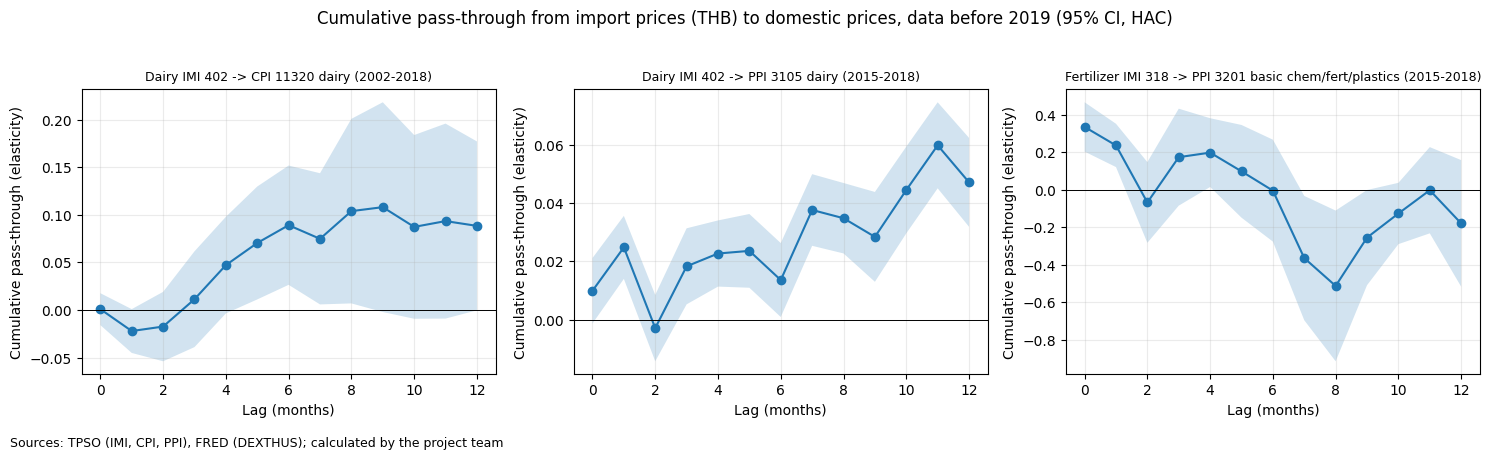

In [7]:
import statsmodels.api as sm

PASS_END = pd.Timestamp('2018-12-01')
MAX_LAG = 12
domestic = {}
for key in ('cpi', 'ppi'):
    record = latest_source(f'tpso-{key}-monthly-') if any(
        item['source_id'].startswith(f'tpso-{key}-monthly-') for item in sources) else None
    assert record is not None, f'ไม่พบ {key} ใน sources.json ให้รัน notebook 01 หัวข้อ 9 ก่อน'
    path = RAW_DIR / record['file']
    assert sha256(path) == record['sha256']
    frame = pd.read_csv(path, dtype={'commodityCode': 'string'})
    frame['date'] = pd.to_datetime(dict(year=frame['year'] - 543, month=frame['month'], day=1))
    domestic[key] = frame

fx_monthly = external_monthly['DEXTHUS']['monthly_average']
PAIRS = [
    ('402', 'cpi', '11320', 'IMI 402 นม → CPI 11320 นมและผลิตภัณฑ์นม'),
    ('402', 'ppi', '3105', 'IMI 402 นม → PPI 3105 ผลิตภัณฑ์นม'),
    ('318', 'ppi', '3201', 'IMI 318 ปุ๋ย → PPI 3201 เคมีภัณฑ์ขั้นมูลฐาน ปุ๋ยเคมี พลาสติก'),
]

def cumulative_ci(result, names):
    rows, cov = [], result.cov_params()
    for k in range(len(names)):
        selected = names[:k + 1]
        estimate = result.params[selected].sum()
        se = float(np.sqrt(cov.loc[selected, selected].values.sum()))
        rows.append((k, estimate, estimate - 1.96 * se, estimate + 1.96 * se))
    return pd.DataFrame(rows, columns=['lag', 'cumulative', 'ci_low', 'ci_high'])

pass_rows, cumulative_frames = [], {}
for imi_code, key, code, label in PAIRS:
    import_thb = group_frames[imi_code].set_index('date')['index'] * fx_monthly
    domestic_index = domestic[key].loc[domestic[key]['commodityCode'] == code].set_index('date')['index'].sort_index()
    data = pd.DataFrame({'y': 100 * np.log(domestic_index).diff()})
    x = 100 * np.log(import_thb).diff()
    lag_names = [f'x_lag{k}' for k in range(MAX_LAG + 1)]
    for k, name in enumerate(lag_names):
        data[name] = x.shift(k)
    data = data[data.index <= PASS_END].dropna()
    months = pd.get_dummies(data.index.month, prefix='m', drop_first=True, dtype=float)
    months.index = data.index
    design = sm.add_constant(pd.concat([data[lag_names], months], axis=1))
    result = sm.OLS(data['y'], design).fit(cov_type='HAC', cov_kwds={'maxlags': MAX_LAG})
    cumulative = cumulative_ci(result, lag_names)
    cumulative_frames[label] = cumulative
    total = cumulative['cumulative'].iloc[-1]
    median_lag = (int(cumulative.loc[cumulative['cumulative'] >= 0.5 * total, 'lag'].iloc[0])
                  if total > 0 else None)
    joint_p = float(result.f_test(', '.join(f'{n} = 0' for n in lag_names)).pvalue)
    total_p = float(result.t_test(' + '.join(lag_names) + ' = 0').pvalue)
    pass_rows.append({
        'pair': label, 'start': data.index.min().date(), 'end': data.index.max().date(),
        'n_obs': int(result.nobs), 'n_params': len(result.params),
        'cumulative_12m': total, 'cumulative_12m_ci_low': cumulative['ci_low'].iloc[-1],
        'cumulative_12m_ci_high': cumulative['ci_high'].iloc[-1],
        'p_cumulative_zero': total_p, 'p_all_lags_zero': joint_p,
        'median_lag_months': median_lag,
        'lag_with_largest_b': int(np.argmax(result.params[lag_names].values)),
    })
passthrough = pd.DataFrame(pass_rows)
passthrough.to_csv(METRICS_DIR / '02_passthrough_summary.csv', index=False)
pd.concat([frame.assign(pair=label) for label, frame in cumulative_frames.items()]).to_csv(
    METRICS_DIR / '02_passthrough_cumulative.csv', index=False)
display(passthrough.round(3))

PLOT_TITLES = dict(zip([label for *_, label in PAIRS], [
    'Dairy IMI 402 -> CPI 11320 dairy (2002-2018)',
    'Dairy IMI 402 -> PPI 3105 dairy (2015-2018)',
    'Fertilizer IMI 318 -> PPI 3201 basic chem/fert/plastics (2015-2018)',
]))
fig, axes = plt.subplots(1, len(PAIRS), figsize=(15, 4.5), sharex=True)
for axis, (_, _, _, label) in zip(axes, PAIRS):
    frame = cumulative_frames[label]
    axis.fill_between(frame['lag'], frame['ci_low'], frame['ci_high'], alpha=0.2)
    axis.plot(frame['lag'], frame['cumulative'], marker='o')
    axis.axhline(0, color='black', linewidth=0.7)
    axis.set_title(PLOT_TITLES[label], fontsize=9)
    axis.set_xlabel('Lag (months)')
    axis.set_ylabel('Cumulative pass-through (elasticity)')
    axis.grid(alpha=0.25)
fig.suptitle('Cumulative pass-through from import prices (THB) to domestic prices, data before 2019 (95% CI, HAC)')
fig.text(0.01, 0.01, 'Sources: TPSO (IMI, CPI, PPI), FRED (DEXTHUS); calculated by the project team', fontsize=9)
fig.tight_layout(rect=(0, 0.04, 1, 0.95))
fig.savefig(FIGURES_DIR / '02_passthrough_cumulative.png', dpi=180, bbox_inches='tight')
plt.show()

In [8]:
pt = passthrough.set_index('pair')
cpi_label, ppi_dairy_label, ppi_fert_label = (label for *_, label in PAIRS)
cpi_cum = cumulative_frames[cpi_label]
first_sig_lag = cpi_cum.loc[cpi_cum['ci_low'] > 0, 'lag'].min()
display(Markdown(f"""
**สรุป pass-through (ข้อมูลก่อน 2019-01)**

- **นม → CPI (ผลหลัก, n = {pt.loc[cpi_label, 'n_obs']})**
  - cumulative pass-through 12 เดือนเท่ากับ {pt.loc[cpi_label, 'cumulative_12m']:.3f} (95% CI {pt.loc[cpi_label, 'cumulative_12m_ci_low']:.3f} ถึง {pt.loc[cpi_label, 'cumulative_12m_ci_high']:.3f}, p = {pt.loc[cpi_label, 'p_cumulative_zero']:.3f}) หมายความว่าราคานำเข้าในรูปบาทเพิ่ม 10% สัมพันธ์กับ CPI นมเพิ่มประมาณ {10 * pt.loc[cpi_label, 'cumulative_12m']:.2f}% ภายใน 12 เดือน
  - การทดสอบร่วมว่าทุก lag เป็นศูนย์ได้ p = {pt.loc[cpi_label, 'p_all_lags_zero']:.1e}
  - median lag เท่ากับ {pt.loc[cpi_label, 'median_lag_months']:.0f} เดือน และ cumulative เริ่มมี CI ไม่คร่อมศูนย์ที่ lag {first_sig_lag} เดือน
  - การส่งผ่านเกิดช้าและเพียงบางส่วน ส่วนหนึ่งเพราะ CPI นมรวมนมที่ผลิตในประเทศและราคาขายปลีกด้วย
- **นม → PPI 3105 (n = {pt.loc[ppi_dairy_label, 'n_obs']}, จำนวนพารามิเตอร์ {pt.loc[ppi_dairy_label, 'n_params']})**
  - cumulative เท่ากับ {pt.loc[ppi_dairy_label, 'cumulative_12m']:.3f} และ median lag {pt.loc[ppi_dairy_label, 'median_lag_months']:.0f} เดือน
  - จำนวน observation ใกล้กับจำนวนพารามิเตอร์ HAC standard error จึงน่าจะแคบเกินจริง ถือเป็นหลักฐานอ่อน
- **ปุ๋ย → PPI 3201 (n = {pt.loc[ppi_fert_label, 'n_obs']})**
  - cumulative ช่วง lag 0–1 เป็นบวก ({cumulative_frames[ppi_fert_label]['cumulative'].iloc[1]:.3f} ที่ lag 1) แล้วกลับทิศ ค่ารวม 12 เดือนเท่ากับ {pt.loc[ppi_fert_label, 'cumulative_12m']:.3f} (p = {pt.loc[ppi_fert_label, 'p_cumulative_zero']:.2f})
  - ไม่พบหลักฐานว่าราคาในประเทศตามหลังราคานำเข้า ผลส่วนใหญ่เกิดภายในเดือนเดียวกันหรือเดือนถัดไป
  - PPI 3201 รวมพลาสติก และข้อมูลสั้น จึงยืนยันระยะเตือนของกลุ่มปุ๋ยไม่ได้

**ผลต่อการเล่าประโยชน์ (RQ4ข):** ในข้อมูลก่อน 2019 การเปลี่ยนแปลงของ CPI นมสัมพันธ์กับราคานำเข้าในรูปบาทย้อนหลัง โดยมี median lag ประมาณ {pt.loc[cpi_label, 'median_lag_months']:.0f} เดือน ค่านี้เป็นค่าประมาณจุดเดียวที่ยังไม่มีช่วงความไม่แน่นอนของ lag และไม่ใช่การทดสอบว่าระบบพยากรณ์ช่วยเตือนราคาที่ SME จ่ายได้จริง จึงเป็นเพียงสมมติฐานของระยะเตือนเพิ่มเติม ขนาดการส่งผ่านเล็ก ส่วนกลุ่มปุ๋ยไม่พบหลักฐานว่ามี lag
"""))
assert (METRICS_DIR / '02_passthrough_summary.csv').exists() and (FIGURES_DIR / '02_passthrough_cumulative.png').exists()


**สรุป pass-through (ข้อมูลก่อน 2019-01)**

- **นม → CPI (ผลหลัก, n = 204)**
  - cumulative pass-through 12 เดือนเท่ากับ 0.088 (95% CI -0.000 ถึง 0.177, p = 0.051) หมายความว่าราคานำเข้าในรูปบาทเพิ่ม 10% สัมพันธ์กับ CPI นมเพิ่มประมาณ 0.88% ภายใน 12 เดือน
  - การทดสอบร่วมว่าทุก lag เป็นศูนย์ได้ p = 6.1e-06
  - median lag เท่ากับ 4 เดือน และ cumulative เริ่มมี CI ไม่คร่อมศูนย์ที่ lag 5 เดือน
  - การส่งผ่านเกิดช้าและเพียงบางส่วน ส่วนหนึ่งเพราะ CPI นมรวมนมที่ผลิตในประเทศและราคาขายปลีกด้วย
- **นม → PPI 3105 (n = 47, จำนวนพารามิเตอร์ 25)**
  - cumulative เท่ากับ 0.047 และ median lag 1 เดือน
  - จำนวน observation ใกล้กับจำนวนพารามิเตอร์ HAC standard error จึงน่าจะแคบเกินจริง ถือเป็นหลักฐานอ่อน
- **ปุ๋ย → PPI 3201 (n = 47)**
  - cumulative ช่วง lag 0–1 เป็นบวก (0.238 ที่ lag 1) แล้วกลับทิศ ค่ารวม 12 เดือนเท่ากับ -0.179 (p = 0.30)
  - ไม่พบหลักฐานว่าราคาในประเทศตามหลังราคานำเข้า ผลส่วนใหญ่เกิดภายในเดือนเดียวกันหรือเดือนถัดไป
  - PPI 3201 รวมพลาสติก และข้อมูลสั้น จึงยืนยันระยะเตือนของกลุ่มปุ๋ยไม่ได้

**ผลต่อการเล่าประโยชน์ (RQ4ข):** ในข้อมูลก่อน 2019 การเปลี่ยนแปลงของ CPI นมสัมพันธ์กับราคานำเข้าในรูปบาทย้อนหลัง โดยมี median lag ประมาณ 4 เดือน ค่านี้เป็นค่าประมาณจุดเดียวที่ยังไม่มีช่วงความไม่แน่นอนของ lag และไม่ใช่การทดสอบว่าระบบพยากรณ์ช่วยเตือนราคาที่ SME จ่ายได้จริง จึงเป็นเพียงสมมติฐานของระยะเตือนเพิ่มเติม ขนาดการส่งผ่านเล็ก ส่วนกลุ่มปุ๋ยไม่พบหลักฐานว่ามี lag


## 7. ข้อค้นพบและ checkpoint

สรุปต่อไปนี้สร้างจากค่าที่คำนวณจริงใน notebook

In [9]:
stats_by_code = group_statistics.set_index('commodity_code')
brent_min = int(coverage_summary.set_index('series').loc['DCOILBRENTEU', 'min_non_null_through_24'])
brent_min_months = ', '.join(
    minimum_months.loc[minimum_months['series'] == 'DCOILBRENTEU', 'month'].tolist()
)
fuel_brent_now = correlations.query(
    "commodity_code == '100' and external_series == 'DCOILBRENTEU' and lag_months == 0"
)['pearson_correlation'].iloc[0]
fertilizer_brent_lag1 = correlations.query(
    "commodity_code == '318' and external_series == 'DCOILBRENTEU' and lag_months == 1"
)['pearson_correlation'].iloc[0]

display(Markdown(f'''
- IMI มี 81 รหัสและ 320 เดือน โดยไม่มี duplicate หรือค่า index ว่าง กลุ่ม 315, 401 และ 417 หยุดเผยแพร่ก่อนเดือนล่าสุด แต่ไม่กระทบกลุ่ม 100, 318 และ 402
- ทุกแถวของ IMI มี `createdAt` ค่าเดียวกัน จึงไม่มีข้อมูลประวัติการแก้ไขย้อนหลัง
- ความผันผวนของ log change 2 เดือนเท่ากับ **{stats_by_code.loc['100', 'std_log_change_2m_pct']:.2f}%** สำหรับเชื้อเพลิง, **{stats_by_code.loc['318', 'std_log_change_2m_pct']:.2f}%** สำหรับปุ๋ย และ **{stats_by_code.loc['402', 'std_log_change_2m_pct']:.2f}%** สำหรับนม
- สัดส่วนเดือนที่ดัชนีไม่ขยับเท่ากับ **{stats_by_code.loc['100', 'zero_change_share_pct']:.1f}%**, **{stats_by_code.loc['318', 'zero_change_share_pct']:.1f}%** และ **{stats_by_code.loc['402', 'zero_change_share_pct']:.1f}%** ตามลำดับ
- Brent มีข้อมูลถึงวันที่ 24 ต่ำสุด **{brent_min} วัน** ในเดือน {brent_min_months} ตาม Scope v3 feature หลักใช้ค่าเฉลี่ยเต็มเดือน t+1 และใช้ค่าเฉลี่ยวันที่ 1–24 เป็น sensitivity check
- เดือนที่ Brent มีข้อมูลทั้งเดือนไม่เกิน {LOW_COVERAGE_MAX_DAYS} วัน ได้แก่ {', '.join(low_months)} ค่าว่าง {int(brent_gaps['missing_days'].sum())} วันเป็นวันจันทร์ถึงศุกร์ {int(brent_gaps['missing_on_weekdays'].sum())} วัน และ DEXTHUS มีค่าในวันเดียวกัน {int(brent_gaps['missing_with_fx_value'].sum())} วัน ค่าว่างส่วนใหญ่จึงเป็นช่องว่างของข้อมูลต้นทาง EIA ไม่ใช่วันหยุดตลาดสหรัฐฯ ไฟล์ที่ดาวน์โหลดไม่ระบุเหตุผลของช่องว่าง เดือนเหล่านี้กระทบเฉพาะแถวที่ t ไม่เกิน {latest_affected_t:%Y-%m} ซึ่งอยู่ในช่วง train เริ่มต้น จึงไม่กระทบช่วง validation และ test
- Correlation ร่วมเดือนระหว่างเชื้อเพลิงกับ Brent เท่ากับ **{fuel_brent_now:.3f}** ซึ่งสนับสนุนการใช้กลุ่มเชื้อเพลิงเป็น sanity check ส่วน correlation ระหว่างปุ๋ยกับ Brent lag 1 เดือนเท่ากับ **{fertilizer_brent_lag1:.3f}**
- Correlation เป็นเพียงความสัมพันธ์เชิงสำรวจ ไม่ตีความเป็นเหตุและไม่ใช้ผลส่วนนี้เลือก feature เพิ่มจากที่ล็อกไว้ใน Scope
'''))

assert quality['duplicate_key'].sum() == 0
assert quality.loc[quality['dataset'] == 'IMI', 'missing_value'].iloc[0] == 0
assert set(discontinued['commodity_code']) == {'315', '401', '417'}
assert all(len(group_frames[code]) == 320 for code in GROUPS)
assert brent_min > 0
assert latest_affected_t <= pd.Timestamp('2014-12-01')
assert (METRICS_DIR / '02_brent_low_coverage_months.csv').exists()
assert all((METRICS_DIR / name).exists() for name in [
    '02_data_quality.csv', '02_imi_code_coverage.csv',
    '02_external_monthly_coverage.csv', '02_imi_group_statistics.csv',
    '02_lag_correlations.csv',
])
assert all((FIGURES_DIR / name).exists() for name in [
    '02_external_observation_coverage.png', '02_imi_trends.png',
    '02_imi_two_month_changes.png', '02_lag_correlations.png',
])
print('CHECKPOINT PASSED: เข้าใจความผิดปกติของข้อมูลและยืนยันว่ากลุ่ม 100/318/402 ใช้งานได้')


- IMI มี 81 รหัสและ 320 เดือน โดยไม่มี duplicate หรือค่า index ว่าง กลุ่ม 315, 401 และ 417 หยุดเผยแพร่ก่อนเดือนล่าสุด แต่ไม่กระทบกลุ่ม 100, 318 และ 402
- ทุกแถวของ IMI มี `createdAt` ค่าเดียวกัน จึงไม่มีข้อมูลประวัติการแก้ไขย้อนหลัง
- ความผันผวนของ log change 2 เดือนเท่ากับ **9.12%** สำหรับเชื้อเพลิง, **4.97%** สำหรับปุ๋ย และ **2.88%** สำหรับนม
- สัดส่วนเดือนที่ดัชนีไม่ขยับเท่ากับ **1.3%**, **11.9%** และ **6.0%** ตามลำดับ
- Brent มีข้อมูลถึงวันที่ 24 ต่ำสุด **7 วัน** ในเดือน 2002-11, 2006-03 ตาม Scope v3 feature หลักใช้ค่าเฉลี่ยเต็มเดือน t+1 และใช้ค่าเฉลี่ยวันที่ 1–24 เป็น sensitivity check
- เดือนที่ Brent มีข้อมูลทั้งเดือนไม่เกิน 10 วัน ได้แก่ 2000-12, 2002-11, 2006-03 ค่าว่าง 36 วันเป็นวันจันทร์ถึงศุกร์ 36 วัน และ DEXTHUS มีค่าในวันเดียวกัน 34 วัน ค่าว่างส่วนใหญ่จึงเป็นช่องว่างของข้อมูลต้นทาง EIA ไม่ใช่วันหยุดตลาดสหรัฐฯ ไฟล์ที่ดาวน์โหลดไม่ระบุเหตุผลของช่องว่าง เดือนเหล่านี้กระทบเฉพาะแถวที่ t ไม่เกิน 2006-09 ซึ่งอยู่ในช่วง train เริ่มต้น จึงไม่กระทบช่วง validation และ test
- Correlation ร่วมเดือนระหว่างเชื้อเพลิงกับ Brent เท่ากับ **0.817** ซึ่งสนับสนุนการใช้กลุ่มเชื้อเพลิงเป็น sanity check ส่วน correlation ระหว่างปุ๋ยกับ Brent lag 1 เดือนเท่ากับ **0.306**
- Correlation เป็นเพียงความสัมพันธ์เชิงสำรวจ ไม่ตีความเป็นเหตุและไม่ใช้ผลส่วนนี้เลือก feature เพิ่มจากที่ล็อกไว้ใน Scope


CHECKPOINT PASSED: เข้าใจความผิดปกติของข้อมูลและยืนยันว่ากลุ่ม 100/318/402 ใช้งานได้


In [10]:
process_log_path = ROOT / 'logs' / 'process_log.md'
existing_log = process_log_path.read_text(encoding='utf-8')
marker = 'ขั้นตอน: 02 Data Understanding'
if marker not in existing_log:
    entry = f'''

## [2026-10-05] ขั้นตอน: 02 Data Understanding
**สิ่งที่ทำ:** ตรวจ schema, checksum, duplicate, missing value และความต่อเนื่องของ IMI วิเคราะห์จำนวน observation รายวัน แนวโน้ม ความผันผวน สัดส่วนเดือนที่ดัชนีไม่ขยับ และ lag correlation ระหว่าง IMI กับ DEXTHUS และ DCOILBRENTEU

**ผลที่ได้:** IMI มี {len(imi):,} แถว 81 รหัส 320 เดือน กลุ่ม 100/318/402 มีข้อมูลครบ ความผันผวน log 2 เดือนเท่ากับ {stats_by_code.loc['100', 'std_log_change_2m_pct']:.2f}%, {stats_by_code.loc['318', 'std_log_change_2m_pct']:.2f}% และ {stats_by_code.loc['402', 'std_log_change_2m_pct']:.2f}% ตามลำดับ Brent มีข้อมูลถึงวันที่ 24 ต่ำสุด {brent_min} วันในเดือน {brent_min_months}

**สิ่งที่พบ / ปัญหา:** รหัส 315, 401 และ 417 หยุดเผยแพร่ก่อนเดือนล่าสุด แต่ไม่กระทบสามกลุ่มที่ใช้ ทุกแถว IMI มี createdAt เดียวกันจึงตรวจประวัติ revision ไม่ได้ ข้อมูลรายวันมีค่าว่างในวันหยุด และ Brent บางเดือนมี observation น้อย

**การตัดสินใจและเหตุผล:** ยืนยันใช้กลุ่ม 318 และ 402 เป็นกลุ่มหลักและ 100 เป็น sanity check ตาม Scope ใช้ค่าเฉลี่ยเต็มเดือน t+1 เป็น feature หลักและค่าเฉลี่ยวันที่ 1–24 เป็น sensitivity check ตาม Scope v3 และไม่เพิ่ม feature จาก correlation เชิงสำรวจ

**ขั้นต่อไป:** ดำเนินการ 03 Data Preparation โดยสร้าง target และ feature ตาม forecast origin พร้อมตรวจ data leakage
'''
    with process_log_path.open('a', encoding='utf-8') as handle:
        handle.write(entry)
    print('บันทึกผลลง logs/process_log.md แล้ว')
else:
    print('มีรายการ 02 Data Understanding ใน process log แล้ว จึงไม่บันทึกซ้ำ')

มีรายการ 02 Data Understanding ใน process log แล้ว จึงไม่บันทึกซ้ำ


In [11]:
revision_marker = 'ขั้นตอน: 02 Data Understanding (แก้ไขให้ตรง Scope v3)'
existing_log = process_log_path.read_text(encoding='utf-8')
if revision_marker not in existing_log:
    gap_summary = '; '.join(
        f"{row.month} มีข้อมูล {row.non_null_full_month} วัน ค่าว่างวันที่ {row.missing_dates}"
        for row in brent_gaps.itertuples()
    )
    entry = f"""

## [2026-10-05] {revision_marker}
**สิ่งที่ทำ:** แก้คำอธิบายใน notebook 02 ที่ยังอ้าง forecast origin วันที่ 25 และ sensitivity check วันที่ 17 ให้ตรงกับ Scope v3 และเพิ่มการตรวจเดือนที่ Brent มีข้อมูลน้อยตาม Scope ข้อ 5.3

**ผลที่ได้:** เดือนที่ Brent มีข้อมูลทั้งเดือนไม่เกิน {LOW_COVERAGE_MAX_DAYS} วัน ได้แก่ {gap_summary} ค่าว่างรวม {int(brent_gaps['missing_days'].sum())} วัน เป็นวันจันทร์ถึงศุกร์ {int(brent_gaps['missing_on_weekdays'].sum())} วัน และ DEXTHUS มีค่าในวันเดียวกัน {int(brent_gaps['missing_with_fx_value'].sum())} วัน บันทึกตารางไว้ที่ logs/metrics/02_brent_low_coverage_months.csv

**สิ่งที่พบ / ปัญหา:** ค่าว่างของ Brent ในเดือนดังกล่าวส่วนใหญ่ตรงกับวันที่ตลาดสหรัฐฯ เปิดทำการ (DEXTHUS มีค่า) จึงเป็นช่องว่างของข้อมูลต้นทาง EIA ส่วนวันที่ DEXTHUS ไม่มีค่าด้วยน่าจะเป็นวันหยุดสหรัฐฯ ไฟล์จาก FRED ไม่ระบุเหตุผลของช่องว่าง [ยังไม่ยืนยันสาเหตุเชิงลึก] รายการ log ของขั้น 02 รอบแรกที่อ้าง sensitivity check วันที่ 17 ถูกแทนด้วยรายการนี้

**การตัดสินใจและเหตุผล:** ไม่เติมค่าและไม่ตัดเดือนดังกล่าว ใช้ค่าเฉลี่ยจาก observation ที่มีอยู่ต่อไป เพราะเดือนเหล่านี้กระทบเฉพาะแถวที่ t ไม่เกิน {latest_affected_t:%Y-%m} ซึ่งอยู่ในช่วง train เริ่มต้น ไม่กระทบ validation และ test feature หลักใช้ค่าเฉลี่ยเต็มเดือน t+1 และใช้ค่าเฉลี่ยวันที่ 1–24 เป็น sensitivity check ตาม Scope v3

**ขั้นต่อไป:** ใช้ตาราง processed จากขั้น 03 ฉบับแก้ไข availability ในขั้น 04 Modeling
"""
    with process_log_path.open('a', encoding='utf-8') as handle:
        handle.write(entry)
    print('บันทึกรายการแก้ไขลง logs/process_log.md แล้ว')
else:
    print('มีรายการแก้ไขให้ตรง Scope v3 ใน process log แล้ว จึงไม่บันทึกซ้ำ')

มีรายการแก้ไขให้ตรง Scope v3 ใน process log แล้ว จึงไม่บันทึกซ้ำ


In [12]:
pass_marker = 'ขั้นตอน: 02 Data Understanding (pass-through lag สำหรับ RQ4ข)'
existing_log = process_log_path.read_text(encoding='utf-8')
if pass_marker not in existing_log:
    lines = '; '.join(
        f"{row.pair}: n={row.n_obs}, cumulative 12 เดือน {row.cumulative_12m:.3f} "
        f"(95% CI {row.cumulative_12m_ci_low:.3f} ถึง {row.cumulative_12m_ci_high:.3f}, p={row.p_cumulative_zero:.3f}), "
        f"median lag {'ไม่กำหนด' if pd.isna(row.median_lag_months) else int(row.median_lag_months)}"
        for row in passthrough.itertuples()
    )
    entry = f"""

## [2026-10-05] {pass_marker}
**สิ่งที่ทำ:** วัด pass-through จากราคานำเข้าในรูปบาท (IMI × DEXTHUS) ไปยัง CPI นม (11320), PPI ผลิตภัณฑ์นม (3105) และ PPI 3201 ด้วย distributed lag 0–12 เดือน พร้อม dummy เดือนและ Newey–West HAC ใช้ข้อมูลก่อน 2019-01 เท่านั้น ตาม Scope หัวข้อ 13

**ผลที่ได้:** {lines} บันทึกไว้ที่ logs/metrics/02_passthrough_summary.csv และ 02_passthrough_cumulative.csv

**สิ่งที่พบ / ปัญหา:**
- CPI นมตอบสนองช้าและเพียงบางส่วน: cumulative เริ่มมี CI ไม่คร่อมศูนย์ที่ lag {first_sig_lag} เดือน และการทดสอบร่วมของทุก lag มีนัยสำคัญ
- PPI มีเพียง {pt.loc[ppi_dairy_label, 'n_obs']} observation ต่อ {pt.loc[ppi_dairy_label, 'n_params']} พารามิเตอร์ จึงเป็นหลักฐานอ่อน
- กลุ่มปุ๋ยไม่พบ lag ที่ชัดเจน และ PPI 3201 รวมพลาสติก

**การตัดสินใจและเหตุผล:** ใช้ผลนี้อธิบายประโยชน์ต่อผู้ใช้เท่านั้น ไม่ใช้เลือก feature, horizon หรือ threshold กลุ่มนมเล่าได้ว่าเดือนเป้าหมายอยู่ห่างจากเดือนที่ออก forecast h−2 เดือน ส่วน median lag {pt.loc[cpi_label, 'median_lag_months']:.0f} เดือนเป็นค่าประมาณความสัมพันธ์กับ CPI โดยต้องระบุว่าขนาดการส่งผ่านเล็ก กลุ่มปุ๋ยยังยืนยันระยะเตือนเพิ่มเติมจาก pass-through ไม่ได้

**ขั้นต่อไป:** 04 Modeling ด้วยตาราง h=2–6 จากขั้น 03
"""
    with process_log_path.open('a', encoding='utf-8') as handle:
        handle.write(entry)
    print('บันทึก pass-through ลง logs/process_log.md แล้ว')
else:
    print('มีรายการ pass-through ใน process log แล้ว จึงไม่บันทึกซ้ำ')

มีรายการ pass-through ใน process log แล้ว จึงไม่บันทึกซ้ำ
